# Rectilinear (L1) Voronoi Diagrams

This notebook demonstrates Voronoi diagrams using **Manhattan (L1) distance** instead of Euclidean distance.

## Manhattan Distance

$$d_{L1}((x_1,y_1), (x_2,y_2)) = |x_1-x_2| + |y_1-y_2|$$

### Key Characteristics:
- Boundaries are straight lines at **45-degree angles**
- Regions are **diamond-shaped** (rotated squares)
- Distance increases linearly in both x and y directions
- Useful for **grid-based pathfinding** (like in city streets)

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

%matplotlib inline

## RectilinearVoronoi Class

In [2]:
class RectilinearVoronoi:
    """
    A class to compute and visualize rectilinear (L1) Voronoi diagrams.
    Uses Manhattan distance: d((x1,y1), (x2,y2)) = |x1-x2| + |y1-y2|
    """

    def __init__(self, points, width=10, height=10, resolution=200):
        """
        Initialize the Voronoi diagram with given points.

        Parameters:
        - points: List of (x, y) tuples representing the sites
        - width, height: Dimensions of the area
        - resolution: Resolution for the grid computation
        """
        self.points = np.array(points)
        self.width = width
        self.height = height
        self.resolution = resolution

        # Create grid
        self.x = np.linspace(0, width, resolution)
        self.y = np.linspace(0, height, resolution)
        self.X, self.Y = np.meshgrid(self.x, self.y)

        # Compute Voronoi regions
        self.regions = self.compute_regions()

    def manhattan_distance(self, x1, y1, x2, y2):
        """Calculate Manhattan distance between two points."""
        return np.abs(x1 - x2) + np.abs(y1 - y2)

    def compute_regions(self):
        """Compute Voronoi regions using Manhattan distance."""
        # Initialize grid with -1 (no region assigned)
        grid = -np.ones((self.resolution, self.resolution), dtype=int)

        # For each cell in the grid, find the closest point
        for i in range(self.resolution):
            for j in range(self.resolution):
                x = self.X[i, j]
                y = self.Y[i, j]

                # Calculate distances to all points
                distances = [self.manhattan_distance(x, y, px, py) for px, py in self.points]

                # Find the closest point(s)
                min_dist = min(distances)
                # If there's a tie, we'll mark it as a boundary later
                closest_indices = [idx for idx, d in enumerate(distances) if d == min_dist]

                # If exactly one closest point, assign it
                if len(closest_indices) == 1:
                    grid[i, j] = closest_indices[0]
                else:
                    # This is a boundary cell
                    grid[i, j] = -1

        return grid

    def find_region_boundaries(self):
        """Find the boundaries between regions."""
        boundaries = []
        for i in range(1, self.resolution - 1):
            for j in range(1, self.resolution - 1):
                current = self.regions[i, j]
                neighbors = [
                    self.regions[i - 1, j],
                    self.regions[i + 1, j],
                    self.regions[i, j - 1],
                    self.regions[i, j + 1],
                ]

                # If any neighbor has a different region (and not boundary),
                # this cell is near a boundary
                if current >= 0:
                    for n in neighbors:
                        if n >= 0 and n != current:
                            boundaries.append((self.X[i, j], self.Y[i, j]))
                            break

        return boundaries

    def get_region_contours(self):
        """Extract contour lines for each region."""
        contours = []
        for point_idx in range(len(self.points)):
            # Create a binary mask for this region
            mask = (self.regions == point_idx).astype(float)

            # Add small regions to avoid issues with contour finding
            if np.sum(mask) > 0:
                contours.append(mask)

        return contours

    def plot(self, show_grid=False, show_boundaries=True, show_points=True):
        """Plot the Voronoi diagram."""
        fig, ax = plt.subplots(figsize=(10, 10))

        # Create a color map for the regions
        colors = plt.get_cmap("tab20")

        # Plot each region
        patches = []
        for point_idx in range(len(self.points)):
            # Find all cells belonging to this region
            region_mask = self.regions == point_idx

            if np.any(region_mask):
                # Create a polygon from the convex hull of the region points
                region_points = []
                for i in range(self.resolution):
                    for j in range(self.resolution):
                        if region_mask[i, j]:
                            region_points.append([self.X[i, j], self.Y[i, j]])

                if region_points:
                    # Find convex hull (simplified approach)
                    # For a proper implementation, use scipy.spatial.ConvexHull
                    # Here we'll just use a bounding box approximation for visualization
                    region_points = np.array(region_points)
                    if len(region_points) > 0:
                        # Simple alpha shape (concave hull) approximation
                        # Create a polygon from the outer points
                        _ = (
                            np.min(region_points[:, 0]),
                            np.max(region_points[:, 0]),
                        )
                        _ = (
                            np.min(region_points[:, 1]),
                            np.max(region_points[:, 1]),
                        )

                        # Create a simple polygon (diamond shape approximation for L1 metric)
                        center = self.points[point_idx]

                        # For L1 metric, regions are diamond-shaped around centers
                        # We'll create a diamond polygon
                        diamond_size = 1.5  # Adjust based on spacing
                        diamond = [
                            [center[0], center[1] + diamond_size],  # Top
                            [center[0] + diamond_size, center[1]],  # Right
                            [center[0], center[1] - diamond_size],  # Bottom
                            [center[0] - diamond_size, center[1]],  # Left
                        ]

                        polygon = Polygon(diamond, closed=True, alpha=0.3, color=colors(point_idx))
                        ax.add_patch(polygon)
                        patches.append(polygon)

        # Plot the grid if requested
        if show_grid:
            ax.imshow(
                self.regions,
                extent=[0, self.width, 0, self.height],
                origin="lower",
                alpha=0.1,
                cmap="tab20",
            )

        # Plot boundaries if requested
        if show_boundaries:
            boundaries = self.find_region_boundaries()
            if boundaries:
                bx, by = zip(*boundaries)
                ax.scatter(bx, by, s=1, c="black", alpha=0.5, label="Boundaries")

        # Plot the original points
        if show_points:
            ax.scatter(
                self.points[:, 0],
                self.points[:, 1],
                c="red",
                s=100,
                marker="o",
                edgecolors="black",
                linewidth=2,
                zorder=10,
                label="Sites",
            )

        # Set plot properties
        ax.set_xlim(-1, self.width + 1)
        ax.set_ylim(-1, self.height + 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"Rectilinear (L1) Voronoi Diagram ({len(self.points)} sites)")
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.grid(True, alpha=0.3)
        ax.legend()

        return fig, ax

    def plot_distance_field(self, point_index=0):
        """Plot the distance field from a specific point."""
        fig, ax = plt.subplots(figsize=(10, 10))

        # Calculate distance field for the selected point
        px, py = self.points[point_index]
        distance_field = self.manhattan_distance(self.X, self.Y, px, py)

        # Plot the distance field
        contour = ax.contourf(self.X, self.Y, distance_field, levels=20, alpha=0.7, cmap="viridis")
        plt.colorbar(contour, ax=ax, label=f"Manhattan distance to site {point_index}")

        # Plot all points
        ax.scatter(
            self.points[:, 0],
            self.points[:, 1],
            c="red",
            s=100,
            marker="o",
            edgecolors="black",
            linewidth=2,
            zorder=10,
            label="Sites",
        )

        # Highlight the selected point
        ax.scatter(
            [px],
            [py],
            c="yellow",
            s=200,
            marker="*",
            edgecolors="black",
            linewidth=2,
            zorder=11,
            label=f"Selected site {point_index}",
        )

        # Set plot properties
        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"Manhattan Distance Field from Site {point_index}")
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.grid(True, alpha=0.3)
        ax.legend()

        return fig, ax

## Helper Functions

In [3]:
def generate_random_points(n, width=10, height=10):
    """Generate n random points within the given bounds."""
    return [(random.uniform(1, width - 1), random.uniform(1, height - 1)) for _ in range(n)]

## Demo: Compare Euclidean vs Manhattan Distance

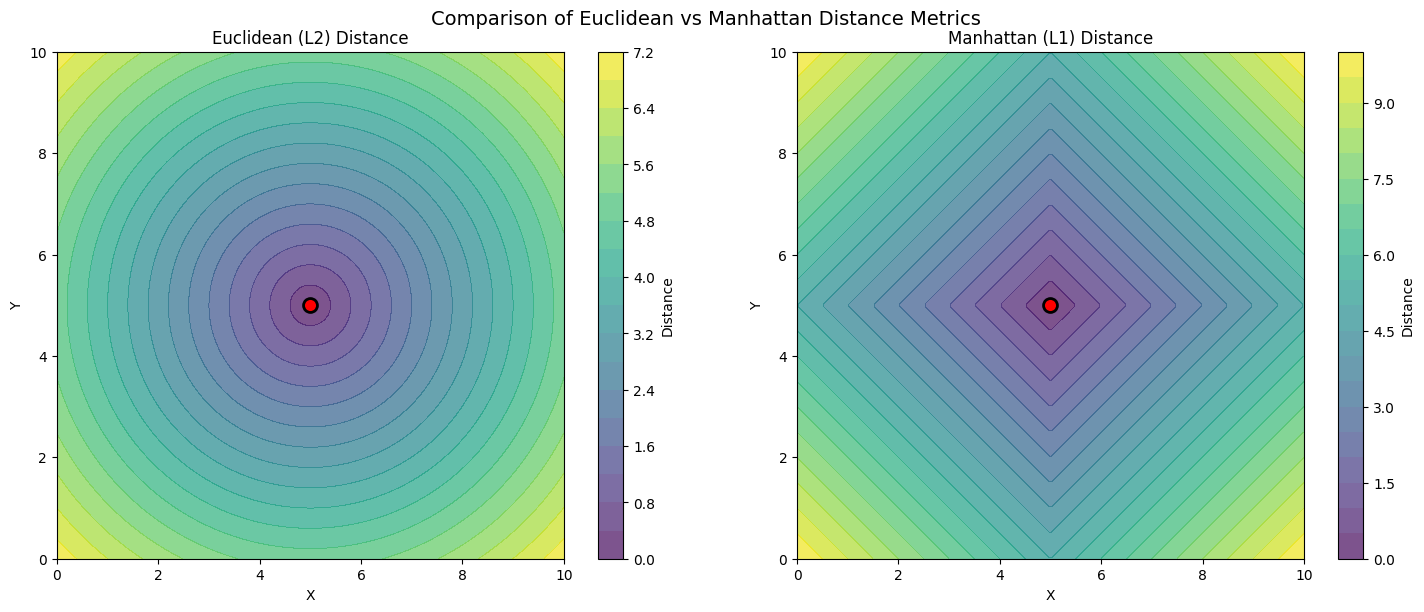

In [4]:
def compare_euclidean_vs_manhattan():
    """Compare Euclidean and Manhattan distances visually."""
    # Create a single point at the center
    center = (5, 5)

    # Create grid
    width, height = 10, 10
    resolution = 200
    x = np.linspace(0, width, resolution)
    y = np.linspace(0, height, resolution)
    X, Y = np.meshgrid(x, y)

    # Calculate distances
    euclidean_dist = np.sqrt((X - center[0]) ** 2 + (Y - center[1]) ** 2)
    manhattan_dist = np.abs(X - center[0]) + np.abs(Y - center[1])

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Euclidean distance
    contour1 = axes[0].contourf(X, Y, euclidean_dist, levels=20, alpha=0.7, cmap="viridis")
    axes[0].scatter(
        [center[0]],
        [center[1]],
        c="red",
        s=100,
        marker="o",
        edgecolors="black",
        linewidth=2,
        zorder=10,
    )
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_title("Euclidean (L2) Distance")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    plt.colorbar(contour1, ax=axes[0], label="Distance")

    # Manhattan distance
    contour2 = axes[1].contourf(X, Y, manhattan_dist, levels=20, alpha=0.7, cmap="viridis")
    axes[1].scatter(
        [center[0]],
        [center[1]],
        c="red",
        s=100,
        marker="o",
        edgecolors="black",
        linewidth=2,
        zorder=10,
    )
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].set_title("Manhattan (L1) Distance")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    plt.colorbar(contour2, ax=axes[1], label="Distance")

    plt.suptitle("Comparison of Euclidean vs Manhattan Distance Metrics", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run the comparison
compare_euclidean_vs_manhattan()

## Demo: Rectilinear Voronoi Diagrams

Example 1: Diamond pattern (4 points)


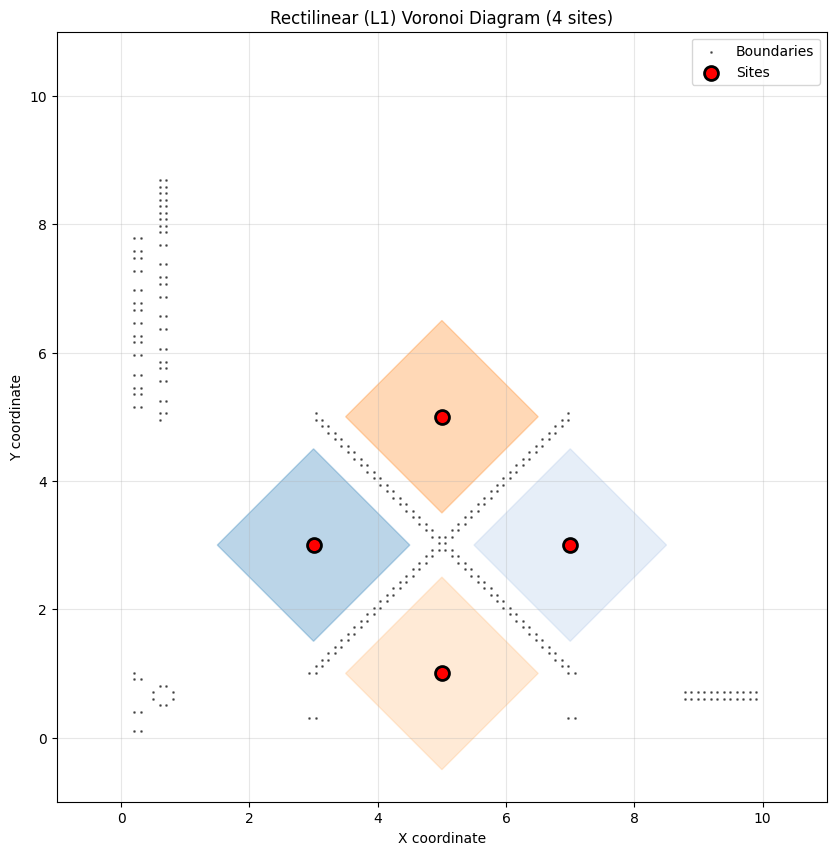

In [5]:
# Example 1: Simple diamond pattern (4 points)
print("Example 1: Diamond pattern (4 points)")
points1 = [(3, 3), (7, 3), (5, 5), (5, 1)]
voronoi1 = RectilinearVoronoi(points1, width=10, height=10, resolution=100)

fig1, ax1 = voronoi1.plot(show_grid=False)
plt.show()

Example 2: Random points (8 points)


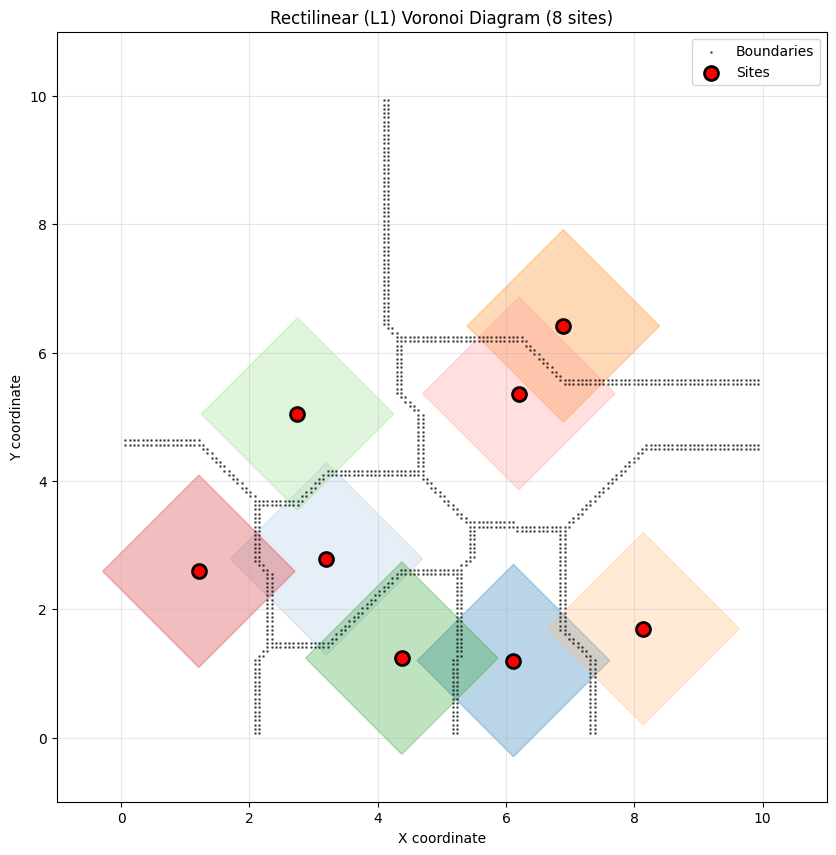

In [6]:
# Example 2: Random points
print("Example 2: Random points (8 points)")
random.seed(42)  # For reproducibility
points2 = generate_random_points(8, width=10, height=10)
voronoi2 = RectilinearVoronoi(points2, width=10, height=10, resolution=150)

fig2, ax2 = voronoi2.plot(show_grid=False)
plt.show()

Example 3: Distance field visualization


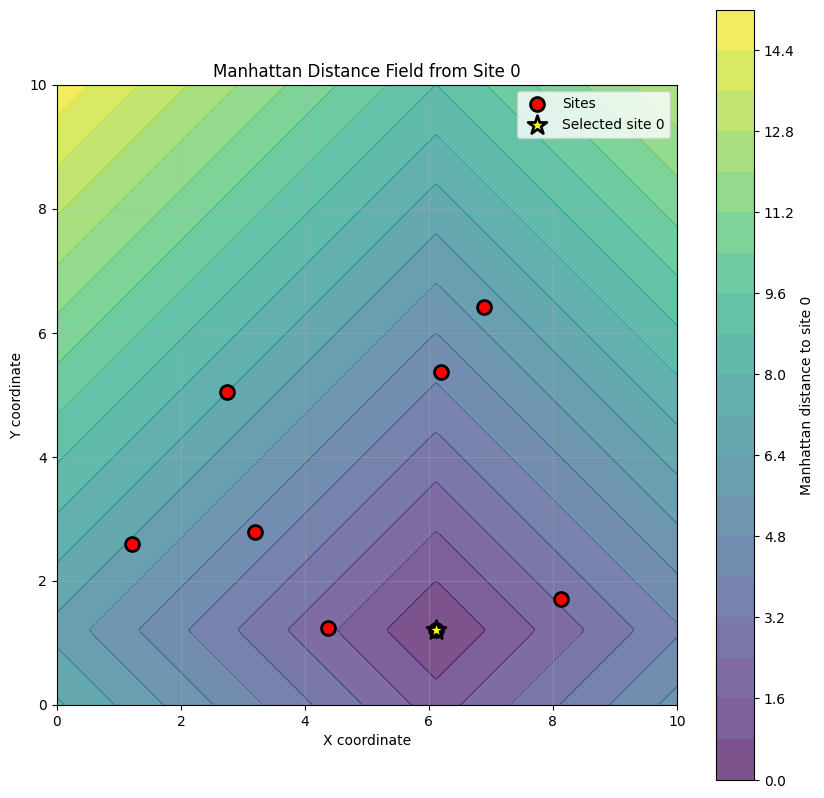

In [7]:
# Example 3: Show distance field from a point
print("Example 3: Distance field visualization")
fig3, ax3 = voronoi2.plot_distance_field(point_index=0)
plt.show()

Example 4: Grid-based visualization


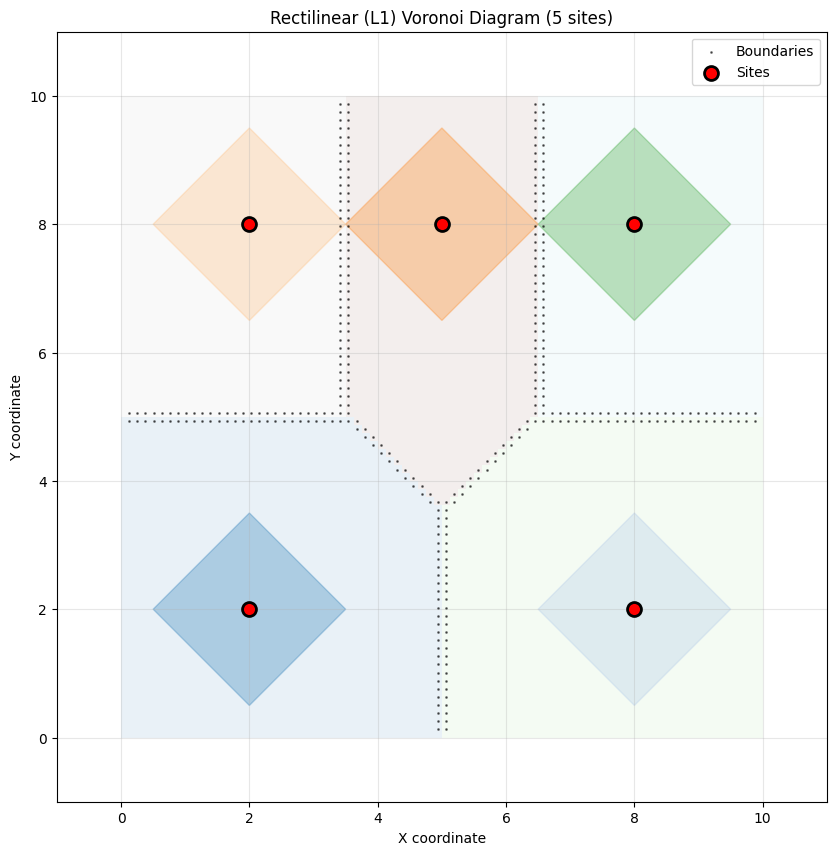

In [8]:
# Example 4: Grid-based visualization
print("Example 4: Grid-based visualization")
points3 = [(2, 2), (8, 2), (5, 8), (2, 8), (8, 8)]
voronoi3 = RectilinearVoronoi(points3, width=10, height=10, resolution=80)

fig4, ax4 = voronoi3.plot(show_grid=True)
plt.show()

## Summary

Key characteristics of rectilinear (L1) Voronoi diagrams:

1. **Boundaries are straight lines at 45-degree angles**
2. **Regions are diamond-shaped** (rotated squares)
3. **Distance increases linearly** in both x and y directions
4. **Useful for grid-based pathfinding** (like in city streets)